In [21]:
from sklearn.datasets import load_diabetes
import pandas as pd
from sklearn.model_selection import train_test_split


diabetes = load_diabetes(as_frame=True)
X = diabetes.data
y = diabetes.target

df = pd.concat([X, y.rename("target")], axis=1)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

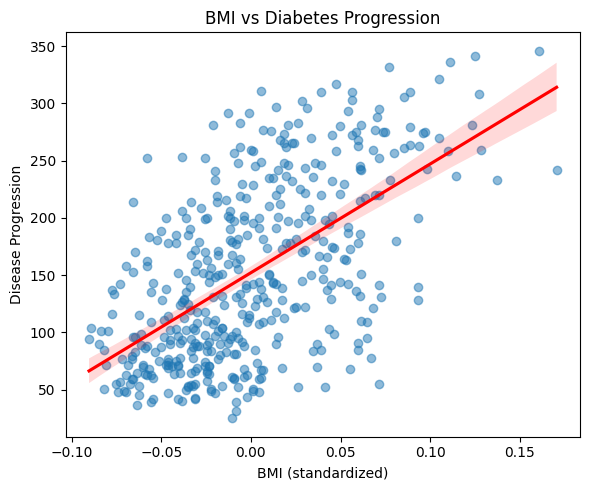

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.regplot(
    x=df["bmi"], 
    y=df["target"],
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"}
)

plt.title("BMI vs Diabetes Progression")
plt.xlabel("BMI (standardized)")
plt.ylabel("Disease Progression")
plt.tight_layout()
plt.show()

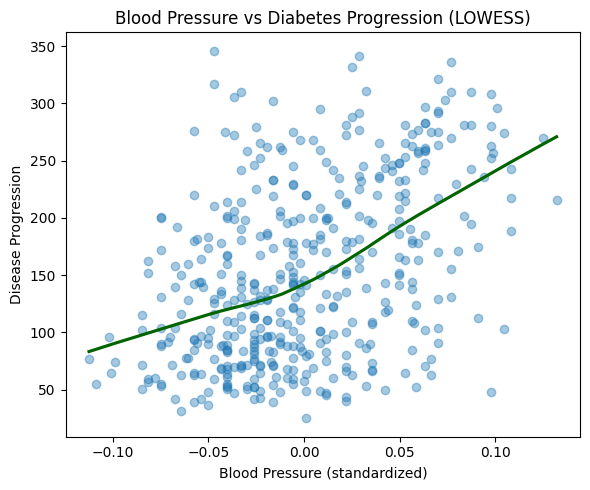

In [19]:
plt.figure(figsize=(6,5))
sns.regplot(
    x=df["bp"],
    y=df["target"],
    lowess=True,
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "darkgreen"}
)

plt.title("Blood Pressure vs Diabetes Progression (LOWESS)")
plt.xlabel("Blood Pressure (standardized)")
plt.ylabel("Disease Progression")
plt.tight_layout()
plt.show()

In [23]:

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Random Forest
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# Gradient Boosting
gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)


In [25]:
from sklearn.metrics import mean_squared_error, r2_score

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, gb_pred))
    ],
    "R²": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, gb_pred)
    ]
})

results

,Model,RMSE,R²
0,Linear Regression,53.853446,0.452603
1,Random Forest,53.482640,0.460115
2,Gradient Boosting,53.183771,0.466132


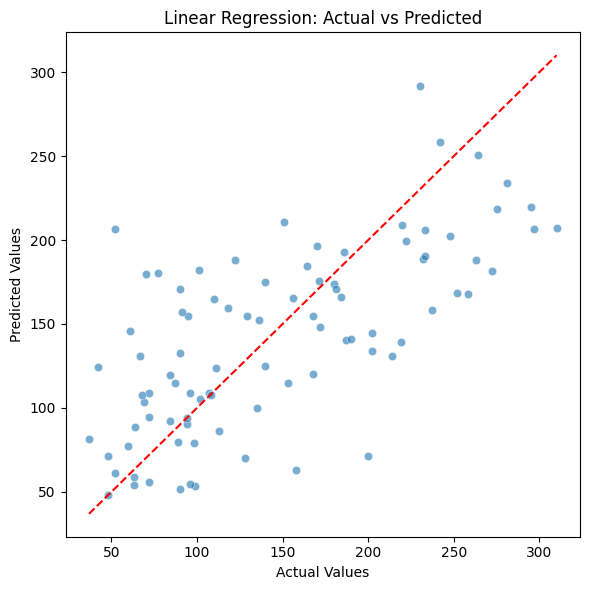

In [27]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=lr_pred, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Linear Regression: Actual vs Predicted")
plt.tight_layout()
plt.show()